In [ ]:
%pip install numpy
%pip install pandas
%pip install matplotlib
%pip install seaborn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv(r"student_performance_result_analytics_500_students.csv")


In [ ]:
df.head()

,Roll No,Student Name,Maths,Science,Computer,English,Total Marks,Result
0,R001,Aarav Kumar,77,92,36,97,302,Pass
1,R002,Akash V,93,89,90,42,314,Pass
2,R003,Ishaan T,95,56,58,72,281,Pass
3,R004,Rahul T,69,98,79,77,323,Pass
4,R005,Rahul R,45,74,35,37,191,Pass


In [ ]:
df.shape


(500, 8)

In [ ]:
df.columns

Index(['Roll No', 'Student Name', 'Maths', 'Science', 'Computer', 'English',
       'Total Marks', 'Result'],
      dtype='object')

In [ ]:
df.dtypes

,0
Roll No,object
Student Name,object
Maths,int64
Science,int64
Computer,int64
English,int64
Total Marks,int64
Result,object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Roll No       500 non-null    object
 1   Student Name  500 non-null    object
 2   Maths         500 non-null    int64 
 3   Science       500 non-null    int64 
 4   Computer      500 non-null    int64 
 5   English       500 non-null    int64 
 6   Total Marks   500 non-null    int64 
 7   Result        500 non-null    object
dtypes: int64(5), object(3)
memory usage: 31.4+ KB


In [ ]:
df.replace(r'^\s*$',np.nan,regex=True,inplace=True)
df.isnull()
df.head()

,Roll No,Student Name,Maths,Science,Computer,English,Total Marks,Result
0,R001,Aarav Kumar,77,92,36,97,302,Pass
1,R002,Akash V,93,89,90,42,314,Pass
2,R003,Ishaan T,95,56,58,72,281,Pass
3,R004,Rahul T,69,98,79,77,323,Pass
4,R005,Rahul R,45,74,35,37,191,Pass


In [ ]:
df.isnull().sum()

,0
Roll No,0
Student Name,0
Maths,0
Science,0
Computer,0
English,0
Total Marks,0
Result,0


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("student_performance_result_analytics_500_students.csv")
def grade(avg):
    if avg >= 90:
        return "A+"
    elif avg >= 80:
        return "A"
    elif avg >= 70:
        return "B"
    elif avg >= 60:
        return "C"
    else:
        return "D"

df["TOTAL_MARKS"] = df["Maths"] + df["Science"] + df["Computer"]+df["English"]
df["Average"] = df["TOTAL_MARKS"] / 3
df["Grade"] = df["Average"].apply(grade)
df["Status"] = df[["Maths","Science","Computer","English"]].apply(
    lambda x: "Pass" if all(x >= 40) else "Fail",
    axis=1
)
display(df)

,Roll No,Student Name,Maths,Science,Computer,English,Total Marks,Result,TOTAL_MARKS,Average,Grade,Status
0,R001,Aarav Kumar,77,92,36,97,302,Pass,302,100.666667,A+,Fail
1,R002,Akash V,93,89,90,42,314,Pass,314,104.666667,A+,Pass
2,R003,Ishaan T,95,56,58,72,281,Pass,281,93.666667,A+,Pass
3,R004,Rahul T,69,98,79,77,323,Pass,323,107.666667,A+,Pass
4,R005,Rahul R,45,74,35,37,191,Pass,191,63.666667,C,Fail
...,...,...,...,...,...,...,...,...,...,...,...,...
495,R496,Arjun T,39,35,83,48,205,Pass,205,68.333333,C,Fail
496,R497,Rahul M,82,86,39,62,269,Pass,269,89.666667,A,Fail
497,R498,Keerthi V,92,49,37,83,261,Pass,261,87.000000,A,Fail
498,R499,Aadhya Raj,56,84,39,38,217,Pass,217,72.333333,B,Fail


/tmp/ipykernel_1042/2399462320.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Grade', data=df, order=['A+', 'A', 'B', 'C', 'D'], palette='viridis')


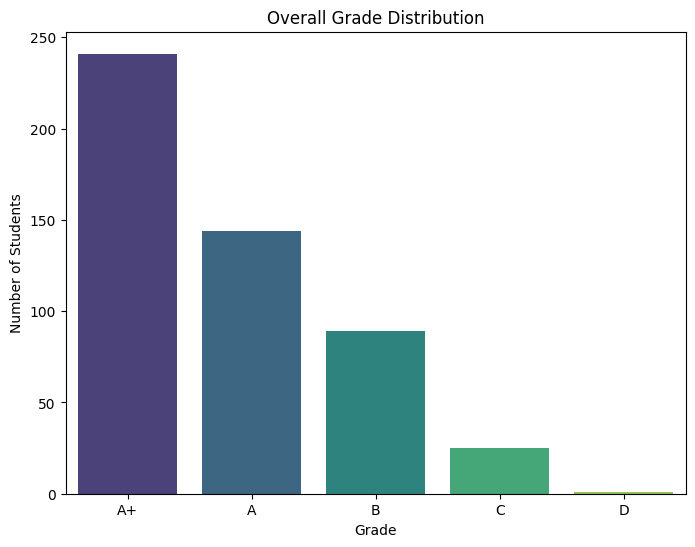

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Grade', data=df, order=['A+', 'A', 'B', 'C', 'D'], palette='viridis')
plt.title('Overall Grade Distribution')
plt.xlabel('Grade')
plt.ylabel('Number of Students')
plt.show()

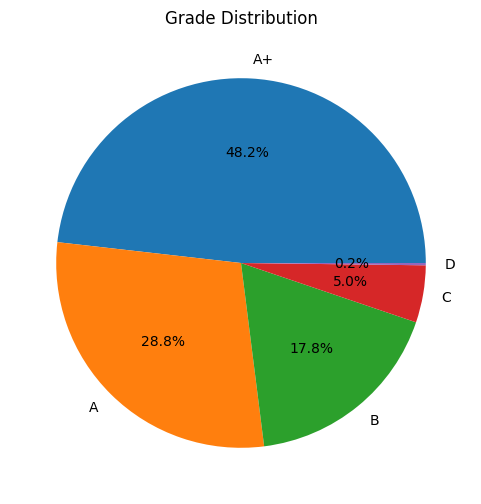

In [ ]:
plt.figure(figsize=(6,6))
df["Grade"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Grade Distribution")
plt.ylabel("")
plt.show()

/tmp/ipykernel_1042/1707787769.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Subject', y='Average Score', data=average_scores, palette='coolwarm')


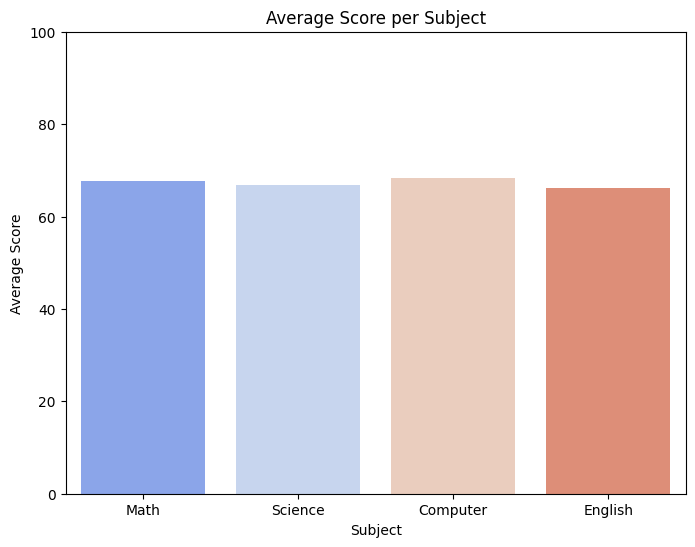

In [ ]:
average_math = df['Maths'].mean()
average_science = df['Science'].mean()
average_computer = df['Computer'].mean()
average_english = df['English'].mean()

average_scores = pd.DataFrame({
    'Subject': ['Math', 'Science', 'Computer','English'],
    'Average Score': [average_math, average_science, average_computer, average_english]
})

plt.figure(figsize=(8, 6))
sns.barplot(x='Subject', y='Average Score', hue='Subject', data=average_scores, palette='coolwarm', legend=False)
plt.title('Average Score per Subject')
plt.xlabel('Subject')
plt.ylabel('Average Score')
plt.ylim(0, 100) # Assuming scores are out of 100
plt.show()

In [27]:
class_result = df.groupby("Grade").agg(
    Students=("Student Name", "count"),
    Average_Marks=("Average", "mean"),
    Highest_Marks=("Average", "max"),
    Lowest_Marks=("Average", "min"),
    Pass_Count=("Status", lambda x: (x == "Pass").sum()),
    Fail_Count=("Status", lambda x: (x == "Fail").sum())
)
display(class_result)

,Students,Average_Marks,Highest_Marks,Lowest_Marks,Pass_Count,Fail_Count
Grade,,,,,,
A,144,84.930556,89.666667,80.0,94,50
A+,241,100.116183,127.666667,90.0,218,23
B,89,75.932584,79.666667,70.0,42,47
C,25,65.400000,69.666667,60.0,6,19
D,1,59.000000,59.000000,59.0,0,1
